In [1]:
# Cell 1: Imports + load trained best model and test set

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score,
)

import pickle

sns.set(style="whitegrid")
pd.set_option("display.max_columns", 200)

data_path = "../data/processed/"

# 1) Load best model
model_path = os.path.join(data_path, "best_model.pkl")
with open(model_path, "rb") as f:
    best_model = pickle.load(f)

# 2) Load test set
test_df = pd.read_csv(os.path.join(data_path, "provider_test_set.csv"))

print("Test set shape:", test_df.shape)
test_df.head()

Test set shape: (1082, 34)


,Provider,ip_claim_count,ip_bene_count,ip_reimb_sum,ip_reimb_mean,ip_admit_days_sum,ip_claim_days_sum,ip_diag_mean,ip_has_operating_rate,op_claim_count,op_bene_count,op_reimb_sum,op_reimb_mean,op_claim_days_sum,op_diag_mean,op_has_operating_rate,provider_bene_count,provider_age_mean,provider_age_std,provider_dead_rate,ChronicCond_Alzheimer_mean,ChronicCond_Heartfailure_mean,ChronicCond_Cancer_mean,total_claim_count,total_reimb_sum,reimb_per_claim,claims_per_bene,reimb_per_bene,ip_claim_share,op_claim_share,total_claim_days_sum,days_per_claim,FraudLabel,row_id
0,PRV51012,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,48.0,31.0,16890.0,351.875000,226.0,2.562500,0.166667,31,76.096443,11.253673,0.000000,1.677419,1.451613,1.903226,48.0,16890.0,351.874993,1.548387,544.838692,0.000000,1.000000,226.0,4.708333,0,7
1,PRV51016,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,6.0,6.0,170.0,28.333333,8.0,3.500000,0.166667,6,70.832763,13.858570,0.000000,1.666667,1.333333,1.500000,6.0,170.0,28.333329,1.000000,28.333329,0.000000,1.000000,8.0,1.333333,0,11
2,PRV51017,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,515.0,420.0,142720.0,277.126214,1214.0,2.704854,0.184466,420,72.817894,12.182620,0.011905,1.611905,1.433333,1.888095,515.0,142720.0,277.126213,1.226190,339.809523,0.000000,1.000000,1214.0,2.357282,0,12
3,PRV51025,13.0,12.0,86000.0,6615.384615,104.0,104.0,7.769231,0.692308,74.0,66.0,32350.0,437.162162,172.0,2.959459,0.229730,76,73.810836,13.249252,0.000000,1.684211,1.473684,1.868421,87.0,118350.0,1360.344812,1.144737,1557.236822,0.149425,0.850575,276.0,3.172414,0,16
4,PRV51027,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,53.0,44.0,29840.0,563.018868,166.0,2.471698,0.207547,44,72.308008,13.962430,0.022727,1.568182,1.340909,1.863636,53.0,29840.0,563.018857,1.204545,678.181803,0.000000,1.000000,166.0,3.132075,0,18


In [2]:
# Cell 2: Prepare features and target for TEST set, then predict

drop_cols = ["FraudLabel", "Provider", "row_id"]
feature_cols = [c for c in test_df.columns if c not in drop_cols]

X_test = test_df[feature_cols]
y_test = test_df["FraudLabel"].astype(int)

# Predictions
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("Fraud ratio in test set:", y_test.mean())

Fraud ratio in test set: 0.0933456561922366


In [3]:
# Cell 3: Classification report + confusion matrix

print("=== Classification Report on TEST set ===")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
cm

=== Classification Report on TEST set ===
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       981
           1       0.68      0.57      0.62       101

    accuracy                           0.94      1082
   macro avg       0.82      0.77      0.79      1082
weighted avg       0.93      0.94      0.93      1082



array([[954,  27],
       [ 43,  58]])

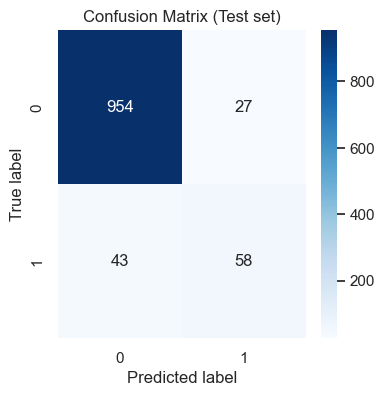

ROC-AUC on TEST: 0.942
PR-AUC  on TEST: 0.698


In [4]:
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix (Test set)")
plt.show()

# Scalar metrics used in the report
roc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

print("ROC-AUC on TEST:", round(roc, 3))
print("PR-AUC  on TEST:", round(pr_auc, 3))

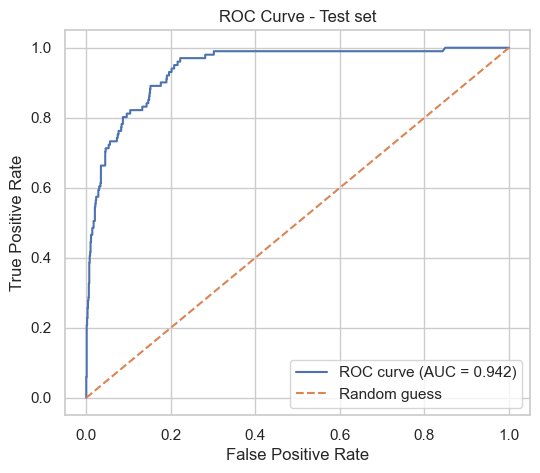

In [5]:
# Cell 4: ROC curve (Test set)

fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test set")
plt.legend()
plt.show()

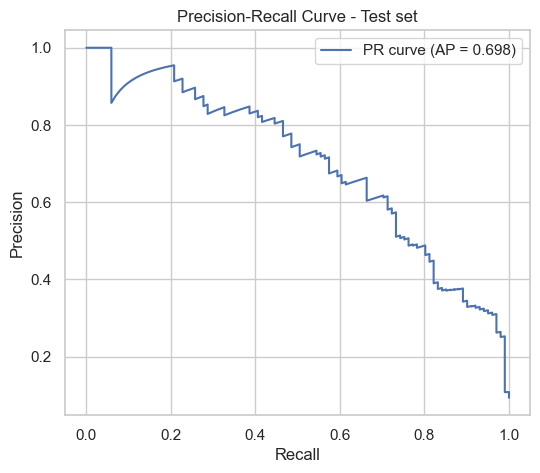

In [6]:
# Cell 5: Precision-Recall curve (Test set)

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"PR curve (AP = {pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Test set")
plt.legend()
plt.show()

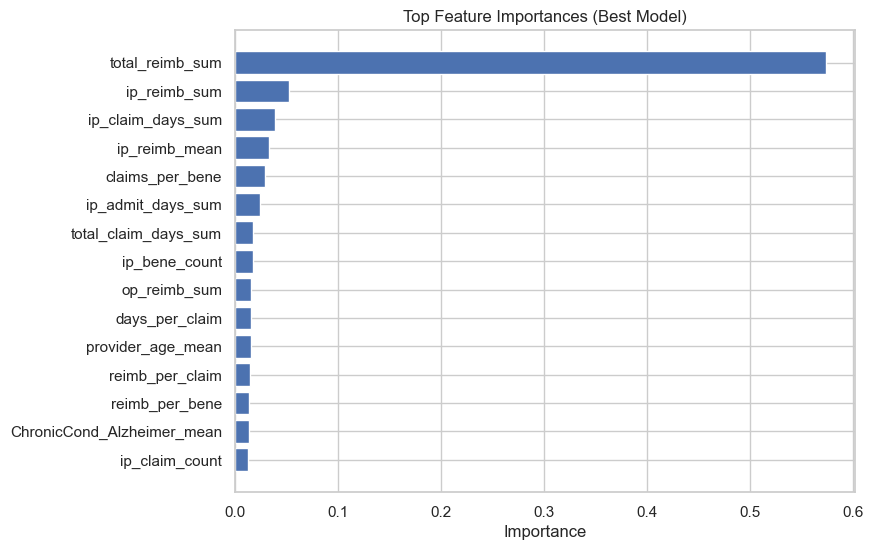

In [7]:
# Cell 6: Feature importances for best model (if supported)

if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1]

    top_n = 15
    top_idx = indices[:top_n]

    plt.figure(figsize=(8, 6))
    plt.barh(
        [feature_cols[i] for i in top_idx][::-1],
        importances[top_idx][::-1]
    )
    plt.xlabel("Importance")
    plt.title("Top Feature Importances (Best Model)")
    plt.show()
else:
    print("The chosen best model does not provide feature_importances_.")

In [8]:
# Cell 7: False Positive (FP) and False Negative (FN) case studies

test_df["pred_label"] = y_pred
test_df["pred_proba"] = y_proba

# False Positives: predicted fraud (1) but actually non-fraud (0)
fp_df = test_df[(test_df["FraudLabel"] == 0) & (test_df["pred_label"] == 1)]
fp_df = fp_df.sort_values("pred_proba", ascending=False)

# False Negatives: predicted non-fraud (0) but actually fraud (1)
fn_df = test_df[(test_df["FraudLabel"] == 1) & (test_df["pred_label"] == 0)]
fn_df = fn_df.sort_values("pred_proba", ascending=True)

print("Number of False Positives:", len(fp_df))
print("Number of False Negatives:", len(fn_df))

# Choose some interpretable columns to inspect
cols_of_interest = [
    "Provider",
    "FraudLabel",
    "pred_label",
    "pred_proba",
    "total_claim_count",
    "total_reimb_sum",
    "reimb_per_claim",
    "claims_per_bene",
    "ip_claim_share",
    "op_claim_share",
    "provider_bene_count",
    "provider_age_mean",
    "provider_dead_rate",
]

print("\n=== Top 3 False Positives (legitimate providers flagged as fraud) ===")
display(fp_df[cols_of_interest].head(3))

print("\n=== Top 3 False Negatives (fraudulent providers missed) ===")
display(fn_df[cols_of_interest].head(3))

Number of False Positives: 27
Number of False Negatives: 43

=== Top 3 False Positives (legitimate providers flagged as fraud) ===


,Provider,FraudLabel,pred_label,pred_proba,total_claim_count,total_reimb_sum,reimb_per_claim,claims_per_bene,ip_claim_share,op_claim_share,provider_bene_count,provider_age_mean,provider_dead_rate
782,PRV55916,0,1,0.970957,127.0,1311040.0,10323.149525,1.198113,0.905512,0.094488,106,75.909186,0.018868
59,PRV51456,0,1,0.936237,135.0,1038990.0,7696.222165,1.088710,0.829630,0.170370,124,75.185843,0.000000
156,PRV52063,0,1,0.918196,792.0,1116210.0,1409.356059,1.087912,0.111111,0.888889,728,74.285474,0.006868



=== Top 3 False Negatives (fraudulent providers missed) ===


,Provider,FraudLabel,pred_label,pred_proba,total_claim_count,total_reimb_sum,reimb_per_claim,claims_per_bene,ip_claim_share,op_claim_share,provider_bene_count,provider_age_mean,provider_dead_rate
877,PRV56523,1,0,0.005015,21.0,6670.0,317.619032,1.05000,0.00,1.00,20,70.233128,0.000000
769,PRV55852,1,0,0.012846,60.0,31730.0,528.833325,1.87500,0.05,0.95,32,76.910849,0.031250
1063,PRV57672,1,0,0.015012,425.0,118190.0,278.094117,1.24269,0.00,1.00,342,74.502163,0.011696
